In [2]:
using DataFrames,PythonPlot,StatsBase,Random,Distributions,CSV,DSP,NLsolve
PythonPlot.svg(true)
include("model.jl")
include("formulas.jl")
FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/cell_cycle_growth/"

"/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/cell_cycle_growth/"

In [5]:
data= CSV.read("./output/ratio_data_cells.csv",DataFrame);
data
arange = data.a |> unique |> sort;
brange = data.b |> unique |> sort;

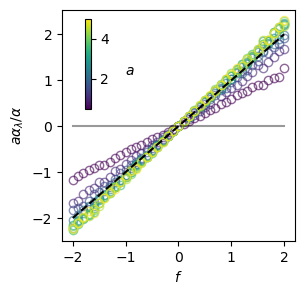

In [7]:
cmap = get_cmap("viridis")
norm_min, norm_max = minimum(arange), maximum(arange)


fig,axs = subplots(figsize=(3, 3),sharex=true)

ax = axs #[0]
j = 0


slopes = []
for a in arange
    df = data[data.a .== a,:]
    j += 1
    α = [-cov(d.ϕ, d.z0) / var(d.z0) for d in groupby(df, :b)]
    αλ = [-cov(d.ϕ ./ d.τ, d.z0) / var(d.z0) * mean(d.τ) for d in groupby(df, :b)]
    push!(slopes,cov(brange,a*αλ ./α)/var(brange))
    color_val = (a - norm_min) / (norm_max - norm_min)
    color = cmap(color_val)
    ax.plot(brange,a*αλ ./α ,"o",color=color,label="\$a = $(a)\$",fillstyle="none",alpha=0.6)
end
ax.plot(brange,zeros(length(brange)),"k-",alpha=0.4)
norm = matplotlib.colors.Normalize(vmin=norm_min, vmax=norm_max)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar_ax = fig.add_axes([0.2, 0.55, 0.02, 0.3])
fig.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel(L"$a$", rotation=0, labelpad=15)


#ax.legend(bbox_to_anchor=(1, 1),frameon=false)
ax.plot(brange,brange,"k--")
ax.set_ylabel("\$a\\alpha_{\\lambda}/\\alpha \$")
#ax.set_ylim([-0.5,0.5])
ax.set_xlabel(L"$f$")
# ax.set_ylabel("\$\\Sigma_{\\lambda,\\lambda}^{(1)} \$")
savefig(joinpath(FIG_PATH, "fig9.pdf"), bbox_inches="tight", pad_inches=0.1, format="pdf")
fig